In [1]:
using DifferentialEquations
using Plots

c1 = 1.0
c2 = 0.5

L = 1.0
Nx = 200

dx = L/(Nx-1)

x = range(0, L, length=Nx)

# for plotting
θ = π .* (x ./ L)

# Initial conditions
u0 = ones(Nx)
v0 = ones(Nx)

Y0 = vcat(u0, v0)

function coupled_transport!(dY, Y, p, t)
    c1, c2, dx, Nx = p

    u = @view Y[1:Nx]
    v = @view Y[Nx+1:2Nx]

    du = @view dY[1:Nx]
    dv = @view dY[Nx+1:2Nx]

    # Coupled boundary conditions
    uL = 0.85*v[end]
    vL = 1.15*u[end]

    # Left boundary points
    du[1] = -c1 * (u[1] - uL)/dx
    dv[1] = -c2 * (v[1] - vL)/dx

    # Interior
    for i in 2:Nx
        du[i] = -c1 * (u[i] - u[i-1])/dx
        dv[i] = -c2 * (v[i] - v[i-1])/dx
    end
end

tspan = (0.0, 8.0)

prob = ODEProblem(
    coupled_transport!,
    Y0,
    tspan,
    (c1, c2, dx, Nx)
)

sol = solve(prob, Tsit5(), saveat=0.01)

retcode: Success
Interpolation: 1st order linear
t: 801-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1
 0.11
 0.12
 ⋮
 7.89
 7.9
 7.91
 7.92
 7.93
 7.94
 7.95
 7.96
 7.97
 7.98
 7.99
 8.0
u: 801-element Vector{Vector{Float64}}:
 [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
 [0.8708629899348058, 0.909421469074326, 0.9558336937132113, 0.9749018038914826, 0.9939311974373105, 0.9975838284000612, 0.9991633601912355, 0.9998373670875749, 0.9999652144591682, 0.9999999616428618  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
 [0.8528722584755424, 0.8637196930832497, 0.8863613152180386, 0.9156695052070561, 0.9449214737281347, 0.9679508746941895, 0.9839274912082583, 0.9924535759848663, 0.9969009687110224, 0.9988483905713864  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
 [0.8503725328483466, 0.8526626484388695, 0.8595096645451952, 0.873160194683248, 0.8933284828663782, 0.9175431133445

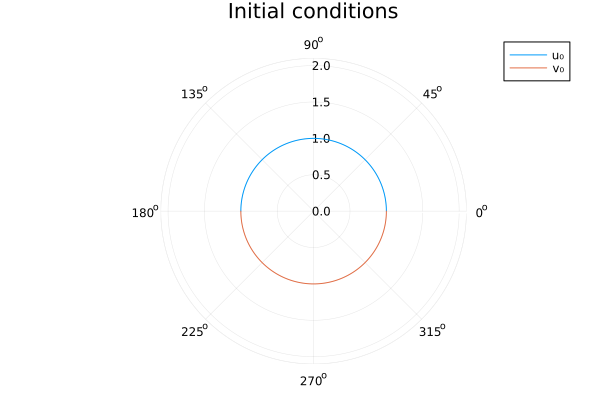

In [2]:
θ = π * x ./ L
plot(
    θ, u0,
    label = "u₀",
    proj = :polar,
    title = "Initial conditions",
    xticks = (0:pi/4.0:2*pi, ["0","\\pi/4", "3", "4", "5", "6", "7", "8"])
    #xticks = (LinRange(0, 2*pi, steps=8)),
)
plot!(
    θ.+pi, v0,
    label = "v₀",
)

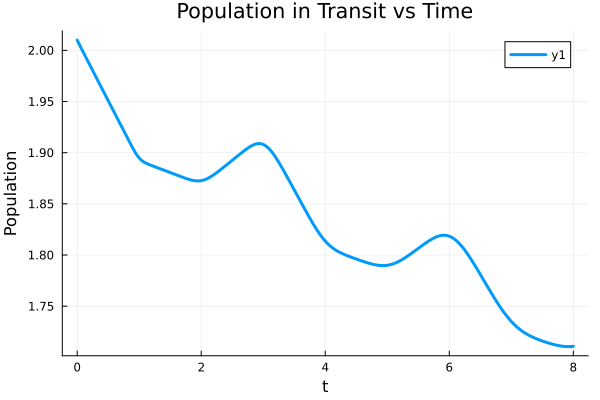

In [3]:
energy = [
    sum(u[1:Nx].^2 .+ u[Nx+1:end].^2)*dx
    for u in sol.u
]

plot(sol.t, energy,
    xlabel="t",
    ylabel="Population",
    title="Population in Transit vs Time",
    linewidth=3)

[ Info: Saved animation to /Users/appelj@moravian.edu/Documents/2026/Spring/math540/project/jp_ring_transport.gif


Plots.AnimatedGif("/Users/appelj@moravian.edu/Documents/2026/Spring/math540/project/jp_ring_transport.gif")
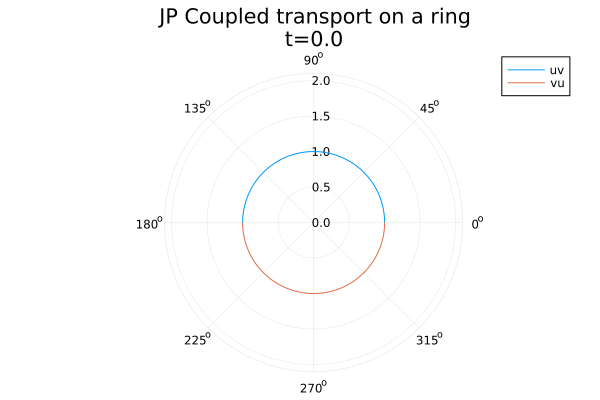

In [4]:
anim = @animate for k in 1:length(sol.t)

    Puv = sol.u[k][1:Nx]
    Pvu = sol.u[k][Nx+1:2Nx]


    plot(
        θ, Puv,
        label="uv",
        proj = :polar,
        legend=:topright,
        title="JP Coupled transport on a ring\nt=$(round(sol.t[k], digits=2))"
    )
    plot!(
        θ.+pi, Pvu,
        label="vu",
    )

end

gif(anim, "jp_ring_transport.gif", fps=25)